### Imports

In [4]:
from fundus_dataset import AugmentPair, FundusVesselDataset, CenterCropPair
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from monai.networks.nets import UNet
from monai.losses import DiceLoss
from safetensors.torch import save_file
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Testing the Dataset

In [2]:
img_dir = "fundus/train/Original/"
mask_dir = "fundus/train/Ground truth"

train_full = FundusVesselDataset(
    img_dir=img_dir,
    mask_dir=mask_dir,
    transform=AugmentPair(crop_size=(512, 512)),
)

val_full = FundusVesselDataset(
    img_dir=img_dir,
    mask_dir=mask_dir,
    transform=None,
)

num_samples = len(train_full)
generator = torch.Generator().manual_seed(42)

# Shuffle the indices
indices = torch.randperm(num_samples, generator=generator).tolist()

train_size = int(0.8 * num_samples)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")

images, masks = next(iter(train_loader))
val_images, val_masks = next(iter(val_loader))

print("Train images:", images.shape, images.dtype, images.min().item(), images.max().item())
print("Train masks: ", masks.shape, masks.dtype, torch.unique(masks))

print("Val images:", val_images.shape, val_images.dtype, val_images.min().item(), val_images.max().item())
print("Val masks: ", val_masks.shape, val_masks.dtype, torch.unique(val_masks))

Number of images: 600
Number of masks: 600
First 5 image files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
First 5 mask files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
Number of images: 600
Number of masks: 600
First 5 image files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
First 5 mask files:  ['100_A.png', '101_A.png', '102_A.png', '103_A.png', '104_A.png']
Train size: 480
Val size: 120
Train images: torch.Size([4, 3, 512, 512]) torch.float32 0.0 0.95686274766922
Train masks:  torch.Size([4, 1, 512, 512]) torch.float32 tensor([0., 1.])
Val images: torch.Size([1, 3, 2048, 2048]) torch.float32 0.0 1.0
Val masks:  torch.Size([1, 1, 2048, 2048]) torch.float32 tensor([0., 1.])


### BCEDice Loss Functions

In [3]:
class BCEDiceLoss(nn.Module):
    def __init__(self, w_bce=0.5, w_dice=0.5):
        super().__init__()
        self.w_bce = w_bce
        self.w_dice = w_dice

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(sigmoid=True)

    def forward(self, logits, masks):
        bce = self.bce(logits, masks)
        dice = self.dice(logits, masks)

        return self.w_bce * bce + self.w_dice * dice

def hard_dice_score(logits, masks, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    # flatten each image separately: [B, 1, H, W] -> [B, pixels]
    preds = preds.flatten(start_dim=1)
    masks = masks.flatten(start_dim=1)

    intersection = (preds * masks).sum(dim=1)
    denominator = preds.sum(dim=1) + masks.sum(dim=1)

    dice = (2 * intersection + eps) / (denominator + eps)

    return dice.mean()

### U-Net Factory

In [6]:
def make_unet(channels=(16, 32, 64, 128, 256)):
    model = UNet(
        spatial_dims=2,
        in_channels=3,
        out_channels=1,
        channels=channels,
        strides=(2, 2, 2, 2),
        num_res_units=2,
    )
    return model.to(device)

### Training Loop Function

In [5]:
def validate_full_image(model, loader, loss_fn, threshold=0.5):
    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            loss = loss_fn(logits, masks)
            dice = hard_dice_score(logits, masks, threshold=threshold)

            val_loss += loss.item() * images.size(0)
            val_dice += dice.item() * images.size(0)

    val_loss /= len(loader.dataset)
    val_dice /= len(loader.dataset)
    return val_loss, val_dice


def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, save_path=None, save_name="baseline.safetensors"):
    history = []
    best_val_dice = 0.0
    best_epoch = 0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_loss_steps = []

        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = loss_fn(logits, masks)

            loss.backward()
            optimizer.step()

            step_loss = loss.item()
            train_loss += step_loss * images.size(0)
            train_loss_steps.append(step_loss)

        train_loss /= len(train_loader.dataset)

        # Default validation protocol: full-image metrics on val_loader.
        val_loss, val_dice = validate_full_image(
            model=model,
            loader=val_loader,
            loss_fn=loss_fn,
            threshold=0.5,
        )

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_loss_steps": train_loss_steps,
            "val_loss": val_loss,
            "val_dice": val_dice,
        })

        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_epoch = epoch + 1

            if save_path is not None:
                save_dir = Path(save_path)
                save_dir.mkdir(parents=True, exist_ok=True)
                st_path = save_dir / save_name
                save_file(model.state_dict(), st_path)

        print(
            f"Epoch {epoch + 1:03d}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val Dice: {val_dice:.4f} | "
            f"Best: {best_val_dice:.4f} @ {best_epoch}"
        )

    return history

### DANGEROUS (RESET EXPERIMENT)

In [6]:
model = make_unet(channels=(32, 64, 128, 256, 512))
loss_fn = BCEDiceLoss(w_bce=0.5, w_dice=0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 100
SAVE_PATH = "/workspace/models_baseline/"
SAVE_NAME = "baseline.safetensors"

### START OR CONTINUE EXPERIMENT

In [7]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=EPOCHS,
    save_path=SAVE_PATH,
    save_name=SAVE_NAME,
)

Epoch 001/100 | Train loss: 0.6968 | Val loss: 0.6780 | Val Dice: 0.6360 | Best: 0.6360 @ 1
Epoch 002/100 | Train loss: 0.6364 | Val loss: 0.6266 | Val Dice: 0.6560 | Best: 0.6560 @ 2
Epoch 003/100 | Train loss: 0.5776 | Val loss: 0.5630 | Val Dice: 0.7270 | Best: 0.7270 @ 3
Epoch 004/100 | Train loss: 0.5156 | Val loss: 0.4924 | Val Dice: 0.7755 | Best: 0.7755 @ 4
Epoch 005/100 | Train loss: 0.4407 | Val loss: 0.4312 | Val Dice: 0.7700 | Best: 0.7755 @ 4
Epoch 006/100 | Train loss: 0.3859 | Val loss: 0.3670 | Val Dice: 0.7566 | Best: 0.7755 @ 4
Epoch 007/100 | Train loss: 0.3265 | Val loss: 0.2956 | Val Dice: 0.7994 | Best: 0.7994 @ 7
Epoch 008/100 | Train loss: 0.2615 | Val loss: 0.2196 | Val Dice: 0.8378 | Best: 0.8378 @ 8
Epoch 009/100 | Train loss: 0.2280 | Val loss: 0.1853 | Val Dice: 0.8360 | Best: 0.8378 @ 8
Epoch 010/100 | Train loss: 0.1898 | Val loss: 0.1554 | Val Dice: 0.8492 | Best: 0.8492 @ 10
Epoch 011/100 | Train loss: 0.1724 | Val loss: 0.1372 | Val Dice: 0.8578 | Best

### Save your Settings

In [9]:
import pandas as pd

history_df = pd.DataFrame(history)
history_df.to_csv("/workspace/models_baseline/baseline_history.csv", index=False)

### Training Graphs

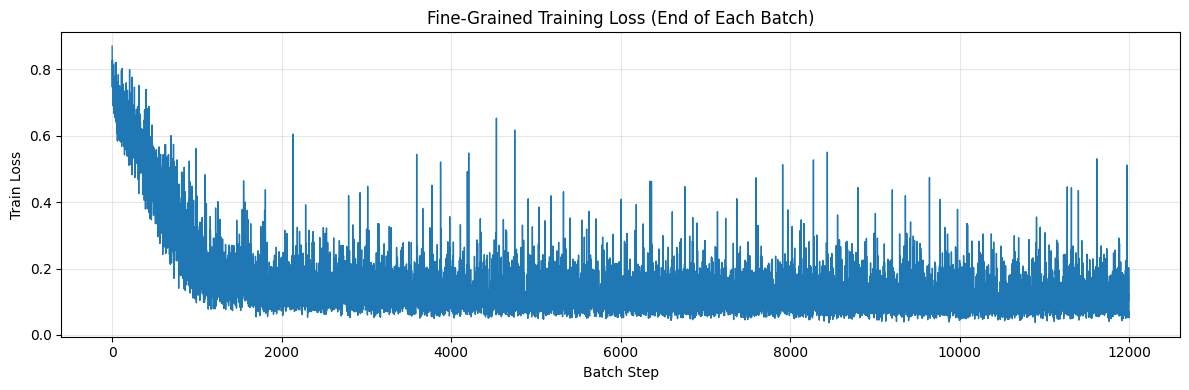

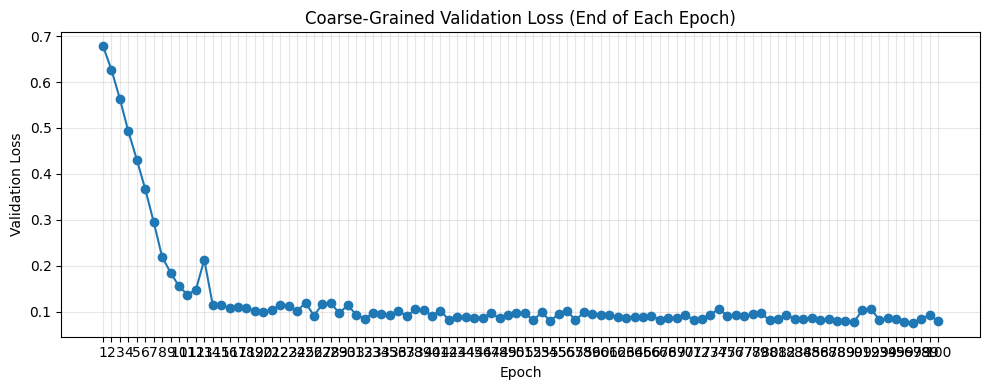

Loaded 100 epochs from /workspace/models_baseline/baseline_history.csv
Plotted 12000 batch-level training-loss points


In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

history_csv = "/workspace/models_baseline/baseline_history.csv"
history_df = pd.read_csv(history_csv)

required_cols = {"epoch", "train_loss_steps", "val_loss"}
missing_cols = required_cols - set(history_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in {history_csv}: {sorted(missing_cols)}")

# Parse stringified step-loss lists safely.
train_loss_steps_per_epoch = history_df["train_loss_steps"].apply(ast.literal_eval)

batch_steps = []
train_step_losses = []
step_idx = 1

for epoch_steps in train_loss_steps_per_epoch:
    batch_steps.extend(range(step_idx, step_idx + len(epoch_steps)))
    train_step_losses.extend(epoch_steps)
    step_idx += len(epoch_steps)

plt.figure(figsize=(12, 4))
plt.plot(batch_steps, train_step_losses, linewidth=1)
plt.title("Fine-Grained Training Loss (End of Each Batch)")
plt.xlabel("Batch Step")
plt.ylabel("Train Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", linewidth=1.5)
plt.title("Coarse-Grained Validation Loss (End of Each Epoch)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loaded {len(history_df)} epochs from {history_csv}")
print(f"Plotted {len(train_step_losses)} batch-level training-loss points")

### Hard Evaluation Functions

Here we load a model safetensors file and then perform inference on it. We will evaluate on the following metrics:


1. Binary Statistics (Dice, IoU, Precision, Recall, F1)
2. $B_0$ and $B_1$ topological errors

In [2]:
import torch


def binary_segmentation_metrics(
    y_true: torch.Tensor,
    y_pred: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-7,
):
    """
    Compute Dice, IoU, precision, recall, and F1 for binary segmentation.

    Args:
        y_true:
            Ground-truth mask. Shape can be [H, W], [1, H, W], or [B, 1, H, W].
            Values should be 0/1.
        
        y_pred:
            Predicted mask or probability map. Same shape as y_true.
            If values are probabilities, they will be thresholded.
            If already binary, thresholding still works.

        threshold:
            Threshold used to binarize y_pred.

        eps:
            Small value to avoid division by zero.

    Returns:
        Dictionary with scalar metric values.
    """

    # Make sure both tensors are detached and flattened
    y_true = y_true.detach()
    y_pred = y_pred.detach()

    # Binarize
    y_true = (y_true > 0.5).float()
    y_pred = (y_pred > threshold).float()

    # Flatten everything into one vector
    y_true = y_true.view(-1)
    y_pred = y_pred.view(-1)

    tp = torch.sum((y_pred == 1) & (y_true == 1)).float()
    fp = torch.sum((y_pred == 1) & (y_true == 0)).float()
    fn = torch.sum((y_pred == 0) & (y_true == 1)).float()
    tn = torch.sum((y_pred == 0) & (y_true == 0)).float()

    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)

    # For binary segmentation, Dice and F1 are mathematically the same
    f1 = (2 * precision * recall + eps) / (precision + recall + eps)

    return {
        "dice": dice.item(),
        "iou": iou.item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "f1": f1.item(),
        "tp": tp.item(),
        "fp": fp.item(),
        "fn": fn.item(),
        "tn": tn.item(),
    }

### Firm Evaluation Functions

The hard versions of the Losses: clDice, Skeleton Recall, cbDice

### Perform Evaluation

In [7]:
from statistics import mean
from safetensors.torch import load_file

test_img_dir = "fundus/test/Original/"
test_mask_dir = "fundus/test/Ground truth"

test_ds = FundusVesselDataset(
    img_dir=test_img_dir,
    mask_dir=test_mask_dir,
    transform=None,
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
)

eval_model = make_unet(channels=(32, 64, 128, 256, 512))
eval_model.load_state_dict(
    load_file("/workspace/models_baseline/baseline.safetensors")
)
eval_model.eval()

per_image_metrics = {}

with torch.no_grad():
    for batch_idx, (images, masks) in enumerate(test_loader):
        name = test_ds.images[batch_idx]
        images = images.to(device)
        masks = masks.to(device)
        probs = torch.sigmoid(eval_model(images))
        per_image_metrics[name] = binary_segmentation_metrics(
            masks, probs, threshold=0.5
        )

metric_keys = ("dice", "iou", "precision", "recall", "f1")
mean_metrics = {k: mean(per_image_metrics[n][k] for n in per_image_metrics) for k in metric_keys}

print("Mean binary metrics (test set):")
for k, v in mean_metrics.items():
    print(f"  {k}: {v:.6f}")


Number of images: 200
Number of masks: 200
First 5 image files:  ['100_D.png', '101_G.png', '102_G.png', '103_G.png', '104_G.png']
First 5 mask files:  ['100_D.png', '101_G.png', '102_G.png', '103_G.png', '104_G.png']
Mean binary metrics (test set):
  dice: 0.871277
  iou: 0.783450
  precision: 0.896569
  recall: 0.852270
  f1: 0.871277


### Scratchpad Code (Don't Bother Deleting anything Below This. It's Junk)

In [ ]:
import json

config = {
    "model": "MONAI UNet",
    "channels": [32, 64, 128, 256, 512],
    "loss": "0.5 BCEWithLogitsLoss + 0.5 DiceLoss(sigmoid=True)",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs": 100,
    "crop_size": [512, 512],
    "batch_size": 4,
    "train_val_split": "80/20",
    "seed": 42,
    "validation_protocol": "full-image validation",
    "best_val_dice": 0.8916996493935585,
}

with open("/workspace/models/config_bce_dice_unet_wide_100epochs.json", "w") as f:
    json.dump(config, f, indent=2)

In [ ]:
images, masks = next(iter(val_loader))

print("images:", images.shape)
print("masks: ", masks.shape)

model.eval()

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = model(images)

print("logits:", logits.shape)

In [ ]:
def validate_full_image_dice(model, loader, threshold=0.5):
    model.eval()
    total_dice = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            dice = hard_dice_score(logits, masks, threshold=threshold)

            total_dice += dice.item() * images.size(0)

    return total_dice / len(loader.dataset)


full_dice = validate_full_image_dice(
    model=model,
    loader=val_loader,
    threshold=0.5,
)

print("Full-image val Dice:", full_dice)

In [ ]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_dice": 0.8916996493935585,
    "model_config": {
        "spatial_dims": 2,
        "in_channels": 3,
        "out_channels": 1,
        "channels": [32, 64, 128, 256, 512],
        "strides": [2, 2, 2, 2],
        "num_res_units": 2,
    },
    "loss": "0.5 * BCEWithLogitsLoss + 0.5 * DiceLoss(sigmoid=True)",
    "optimizer": "Adam",
    "lr": 1e-3,
    "crop_size": [512, 512],
    "batch_size": 4,
    "seed": 42,
    "validation_protocol": "full-image validation",
}

torch.save(checkpoint, "/workspace/models/bce_dice_unet_wide_rich_checkpoint.pt")

In [ ]:
ckpt = torch.load(
    "/workspace/models/4-30-2026-9-49/bce_dice_unet_wide_rich_checkpoint.pt",
    map_location=device,
)

test_model = make_unet(channels=tuple(ckpt["model_config"]["channels"]))
test_model.load_state_dict(ckpt["model_state_dict"])
test_model.eval()

print("Checkpoint reload successful")

full_dice = validate_full_image_dice(
    model=test_model,
    loader=val_loader,
    threshold=0.5,
)

print("Reloaded full-image val Dice:", full_dice)

In [ ]:
notes = """
Baseline completed.

Dataset: FIVES train split only, 80/20 internal split.
Model: MONAI U-Net, channels=(32,64,128,256,512).
Loss: 0.5 BCE + 0.5 Dice.
Training: random 512x512 crops, batch size 4, Adam lr=1e-3, 100 epochs.
Validation protocol: full-image validation.
Best val Dice (full-image): 0.8916996493935585.
Next step: compare losses under the same full-image validation protocol.
"""

with open("/workspace/models/4-30-2026-9-49/README_baseline.txt", "w") as f:
    f.write(notes)

In [ ]:
import os
import torch
import matplotlib.pyplot as plt

save_dir = "/workspace/models/qualitative"
os.makedirs(save_dir, exist_ok=True)

model.eval()

num_examples_to_save = 8
saved = 0

with torch.no_grad():
    for batch_idx, (images, masks) in enumerate(val_loader):
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        batch_size = images.size(0)

        for idx in range(batch_size):
            if saved >= num_examples_to_save:
                break

            fig = plt.figure(figsize=(12, 4))

            plt.subplot(1, 4, 1)
            plt.imshow(images[idx].cpu().permute(1, 2, 0))
            plt.title("Image")
            plt.axis("off")

            plt.subplot(1, 4, 2)
            plt.imshow(masks[idx, 0].cpu(), cmap="gray")
            plt.title("Ground truth")
            plt.axis("off")

            plt.subplot(1, 4, 3)
            plt.imshow(probs[idx, 0].cpu(), cmap="gray", vmin=0, vmax=1)
            plt.title("Probability")
            plt.axis("off")

            plt.subplot(1, 4, 4)
            plt.imshow(preds[idx, 0].cpu(), cmap="gray", vmin=0, vmax=1)
            plt.title("Prediction")
            plt.axis("off")

            plt.tight_layout()

            out_path = os.path.join(
                save_dir,
                f"bce_dice_val_example_{saved:02d}.png"
            )

            plt.savefig(out_path, dpi=200, bbox_inches="tight")
            plt.close(fig)

            print("Saved:", out_path)

            saved += 1

        if saved >= num_examples_to_save:
            break

print(f"Saved {saved} qualitative examples to {save_dir}")